# Exploratory Data Analysis

### Libraries Import

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

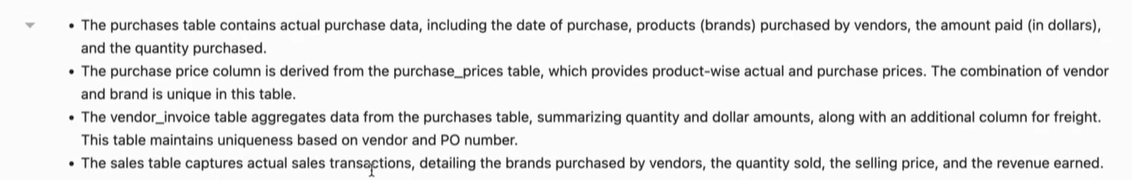

### Data Load

In [26]:
vendor_invoice = pd.read_csv('vendor_invoice.csv')

In [21]:
vendor_invoice.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN


### Data Types

In [27]:
vendor_invoice.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   VendorNumber  5543 non-null   int64  
 1   VendorName    5543 non-null   object 
 2   InvoiceDate   5543 non-null   object 
 3   PONumber      5543 non-null   int64  
 4   PODate        5543 non-null   object 
 5   PayDate       5543 non-null   object 
 6   Quantity      5543 non-null   int64  
 7   Dollars       5543 non-null   float64
 8   Freight       5543 non-null   float64
 9   Approval      374 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 433.2+ KB


### Missing Values

In [28]:
vendor_invoice.isnull().sum()

VendorNumber       0
VendorName         0
InvoiceDate        0
PONumber           0
PODate             0
PayDate            0
Quantity           0
Dollars            0
Freight            0
Approval        5169
dtype: int64

### Duplicate Values

In [29]:
vendor_invoice.duplicated().sum()

0

### Data Distribution

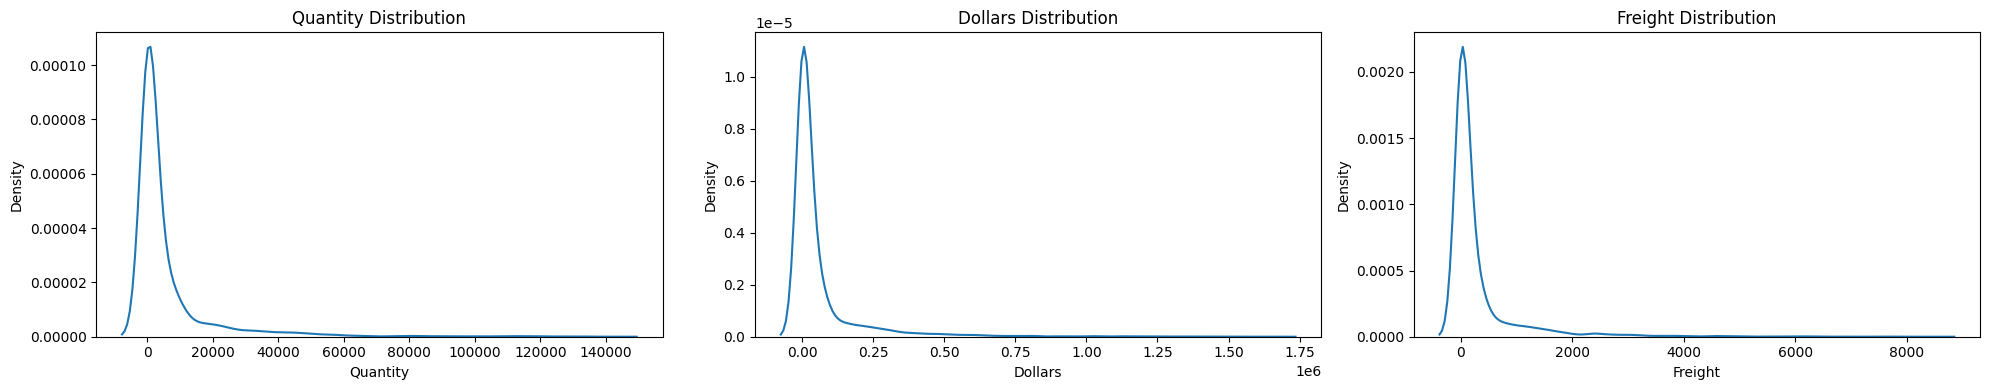

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4))

axes = axes.flatten()

for i, c in enumerate(vendor_invoice[['Quantity', 'Dollars', 'Freight']]):
    sns.kdeplot(data=vendor_invoice, x=c, ax=axes[i])
    axes[i].set_xlabel(c)
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'{c} Distribution')

plt.tight_layout()
plt.show()

### Correlation

In [32]:
vendor_invoice.corr(numeric_only=True)['Freight']

VendorNumber   -0.163493
PONumber        0.043617
Quantity        0.946550
Dollars         0.985141
Freight         1.000000
Name: Freight, dtype: float64

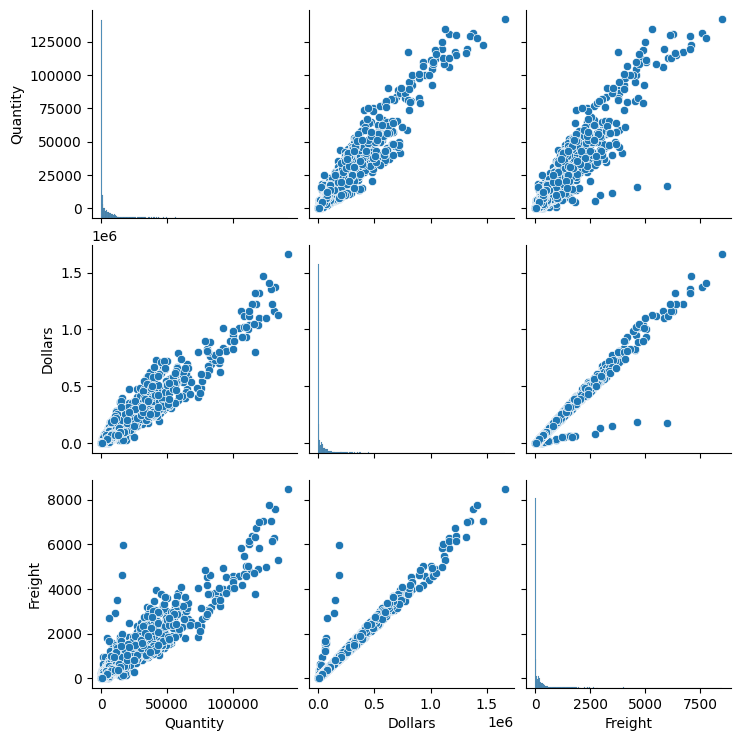

In [50]:
sns.pairplot(vendor_invoice[['Quantity', 'Dollars', 'Freight']])
plt.show()

### Outliers

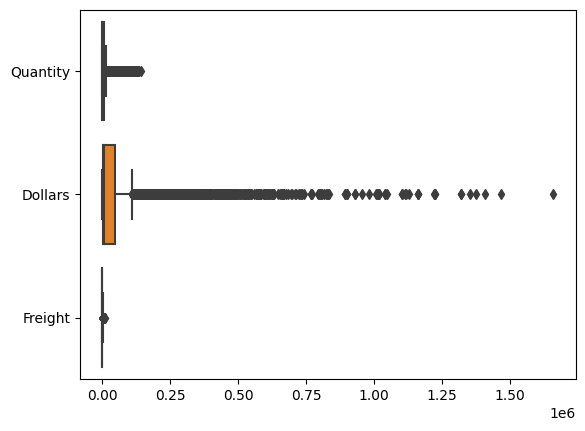

In [53]:
sns.boxplot(vendor_invoice[['Quantity', 'Dollars', 'Freight']], orient='h')
plt.show()